# Part 2: Computer Vision Problem Formulation and CNN Prototype

## Task 1: Problem Identification

The dataset represents a **Image Classification** Computer Vision type of problem
The reasons for this are as follows:
1. Each image is assigned exactly one class label (`normal`, `scratch`, `dent`, or `stain`). There are no bounding boxes, pixel-level masks, or multiple object annotations in the images.
2. The task is to determine *what type* of defect (if any) is present on the product surface (one of the 4 types for which sample images are provided), not *where* on the object it is located. This rules out object detection (which requires bounding boxes) and segmentation (which requires pixel-level masks).
3. Each image belongs to exactly one category. The folder structure and `labels.csv` confirm a clean one-to-one mapping between images and class labels.
4. The entire image represents a single product surface, and the model must classify the overall image into one of four categories.

## Task 2: Dataset Exploration

In [157]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from collections import Counter

BASE_DIR = os.path.join('Data_Sets', 'part_2_cnn_computer_vision')
IMAGES_DIR = os.path.join(BASE_DIR, 'images')
LABELS_CSV = os.path.join(BASE_DIR, 'labels.csv')

df = pd.read_csv(LABELS_CSV)
print(f"Total images in labels.csv: {len(df)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Total images in labels.csv: 480

Columns: ['filename', 'class']

First 5 rows:


,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


In [158]:
# Number of unique classes
classes = sorted(df['class'].unique())
num_classes = len(classes)
print(f"Number of classes: {num_classes}")
print(f"Class names: {classes}")

# Number of images per class
class_counts = df['class'].value_counts().sort_index()
print("Images per class:")
print(class_counts)
print(f"\nTotal images: {class_counts.sum()}")

Number of classes: 4
Class names: ['dent', 'normal', 'scratch', 'stain']
Images per class:
class
dent       120
normal     120
scratch    120
stain      120
Name: count, dtype: int64

Total images: 480


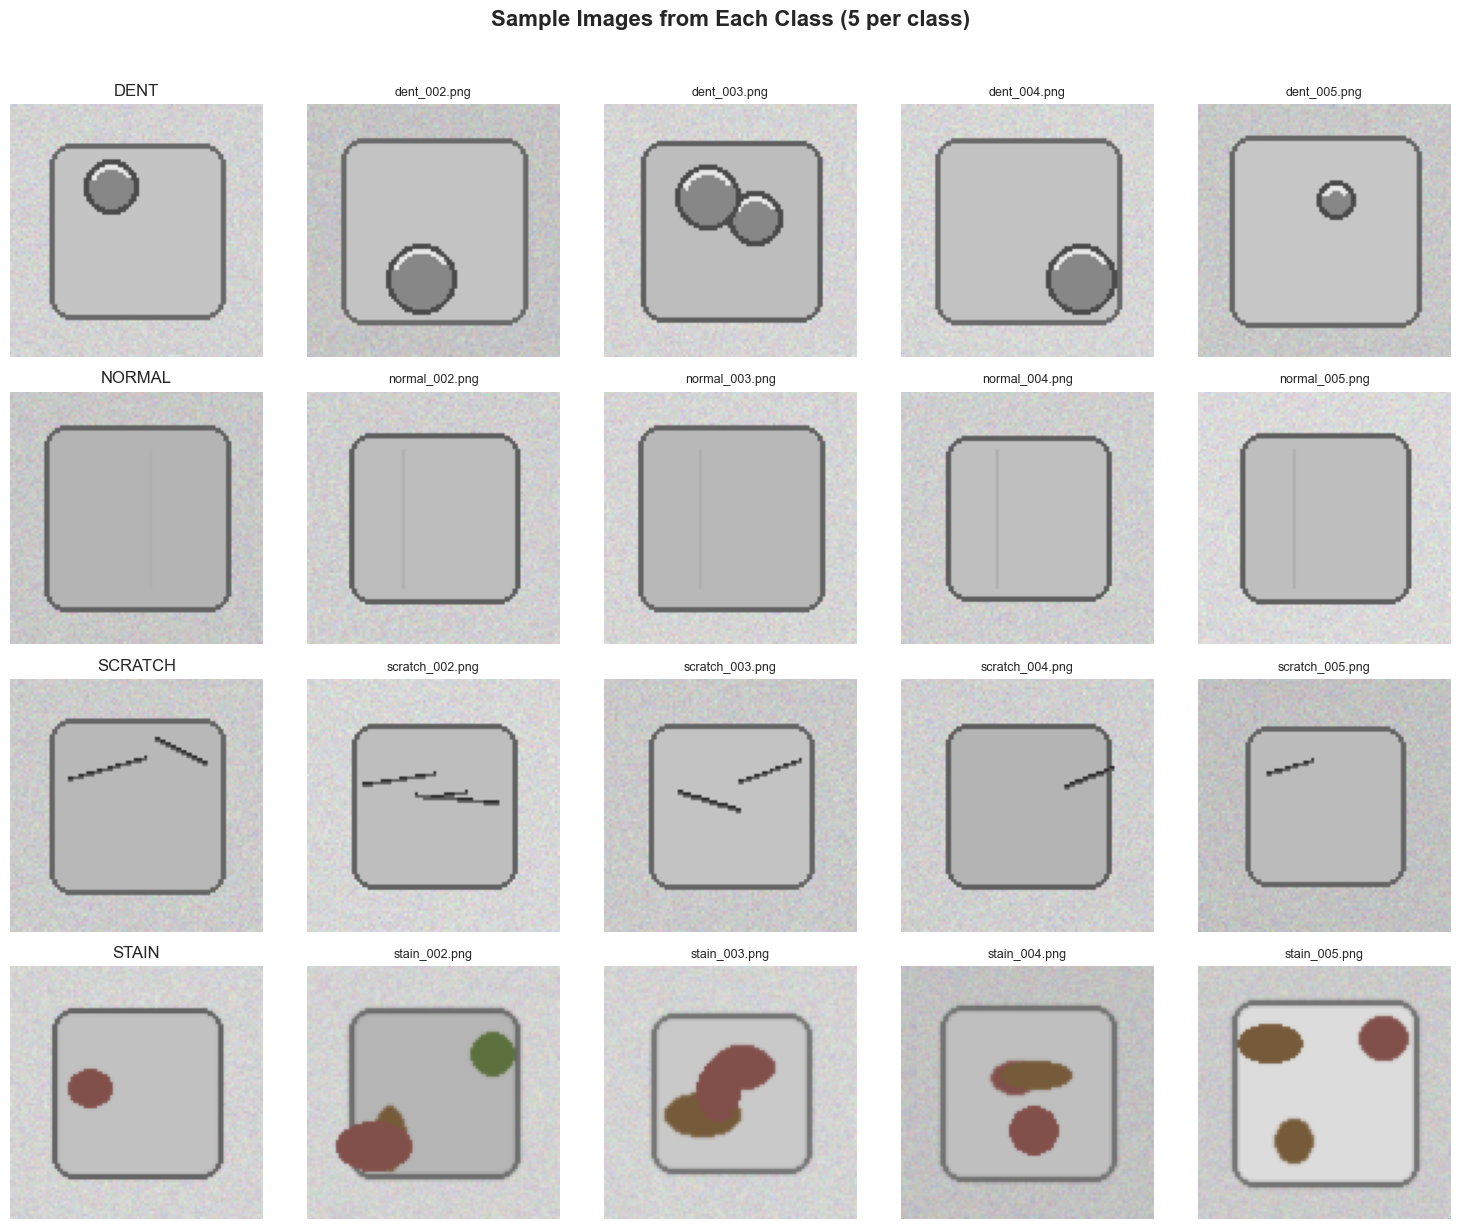

In [159]:
# Showing 5 sample images from each class
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Sample Images from Each Class (5 per class)', fontsize=16, fontweight='bold', y=1.02)

for row_idx, cls in enumerate(classes):
    cls_dir = os.path.join(IMAGES_DIR, cls)
    img_files = sorted([f for f in os.listdir(cls_dir) if f.endswith('.png')])[:5]
    
    for col_idx, img_file in enumerate(img_files):
        img_path = os.path.join(cls_dir, img_file)
        img = Image.open(img_path)
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_title(f'{cls.upper()}')
        else:
            axes[row_idx, col_idx].set_title(img_file, fontsize=9)

plt.tight_layout()
plt.show()


In [160]:
# Showing image dimensions

dimensions = []
modes = []

for _, row in df.iterrows():
    img_path = os.path.join(BASE_DIR, row['filename'])
    img = Image.open(img_path)
    dimensions.append(img.size)  # (width, height)
    modes.append(img.mode)

unique_dims = set(dimensions)
unique_modes = set(modes)

print(f"Unique image dimensions (WxH): {unique_dims}")
print(f"Image color modes: {unique_modes}")
print(f"\nAll images are {'the same size' if len(unique_dims) == 1 else 'different sizes'}")

w, h = dimensions[0]
print(f"Image dimensions: {w} x {h} pixels")
print(f"Color channels: 3 (RGB)")
print(f"Input shape per image: ({h}, {w}, 3)")

Unique image dimensions (WxH): {(96, 96)}
Image color modes: {'RGB'}

All images are the same size
Image dimensions: 96 x 96 pixels
Color channels: 3 (RGB)
Input shape per image: (96, 96, 3)


In [161]:
# Analysing imbalances in the dataset

print("============================")
print("DATASET IMBALANCE ANALYSIS")
print("============================")

total = len(df)
print(f"\nTotal images: {total}")
print(f"Number of classes: {num_classes}")
print(f"Expected per class (balanced): {total // num_classes}")
print()

for cls in classes:
    count = class_counts[cls]
    pct = count / total * 100
    print(f"  {cls:>10s}: {count:4d} images ({pct:.1f}%)")

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio == 1.0:
    print("\nConclusion: The dataset is PERFECTLY BALANCED.")
    print("All classes have exactly the same number of images.")
    print("No resampling, class weighting, or data augmentation strategies are needed to handle imbalance.")
elif imbalance_ratio < 1.5:
    print("\nConclusion: The dataset is approximately balanced (ratio < 1.5).")
else:
    print(f"\nConclusion: The dataset is IMBALANCED (ratio = {imbalance_ratio:.2f}).")
    print("Consider using class weights, oversampling, or data augmentation.")

DATASET IMBALANCE ANALYSIS

Total images: 480
Number of classes: 4
Expected per class (balanced): 120

        dent:  120 images (25.0%)
      normal:  120 images (25.0%)
     scratch:  120 images (25.0%)
       stain:  120 images (25.0%)

Imbalance ratio (max/min): 1.00

Conclusion: The dataset is PERFECTLY BALANCED.
All classes have exactly the same number of images.
No resampling, class weighting, or data augmentation strategies are needed to handle imbalance.


## Task 3: Image Preprocessing

In [162]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory  # type: ignore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [163]:
# Encoding labels to integers using One-Hot Encoding

IMG_SIZE = 96

images = []
labels = []

for _, row in df.iterrows():
    img_path = os.path.join(BASE_DIR, row['filename'])
    img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
    images.append(np.array(img))
    labels.append(row['class'])

X = np.array(images)
y_text = np.array(labels)

le = LabelEncoder()
y_int = le.fit_transform(y_text)
y = tf.keras.utils.to_categorical(y_int, num_classes=4)

print("Label encoding mapping:")
for i, cls_name in enumerate(le.classes_):
    print(f"  {cls_name} -> {i}")

print(f"\nInteger labels shape: {y_int.shape}")
print(f"One-hot encoded shape: {y.shape}")
print(f"\nExample — label '{y_text[0]}' -> integer {y_int[0]} -> one-hot {y[0]}")

Label encoding mapping:
  dent -> 0
  normal -> 1
  scratch -> 2
  stain -> 3

Integer labels shape: (480,)
One-hot encoded shape: (480, 4)

Example — label 'normal' -> integer 1 -> one-hot [0. 1. 0. 0.]


In [165]:
# normalizing pixel values to [0, 1] to bring all pixels to a common scale

X_normalized = X.astype('float32') / 255.0

print(f"Before normalization — dtype: {X.dtype}, range: [{X.min()}, {X.max()}]")
print(f"After normalization  — dtype: {X_normalized.dtype}, range: [{X_normalized.min():.1f}, {X_normalized.max():.1f}]")
print(f"Shape: {X_normalized.shape}")

Before normalization — dtype: uint8, range: [45, 255]
After normalization  — dtype: float32, range: [0.2, 1.0]
Shape: (480, 96, 96, 3)


In [178]:
#Splitting the dataset into training, validation and testing sets. Earlier I was validating on the test set. Instead now I will do a 3 way split (70:15:15)

# First Split: Separate the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X_normalized, y, test_size=0.15, random_state=42, stratify=y)

# Second Split: From the remaining 85%, split into training (70%) and validation (15%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)  # 0.1765 ≈ 15/85


print("==========================")
print("TRAIN-VALIDATION-TEST SPLIT SUMMARY")
print("==========================")
print(f"\nTraining set:  {X_train.shape[0]} images  ({X_train.shape[0]/len(X_normalized)*100:.0f}%)")
print(f"Validation set: {X_val.shape[0]} images  ({X_val.shape[0]/len(X_normalized)*100:.0f}%)")
print(f"Testing set:   {X_test.shape[0]} images  ({X_test.shape[0]/len(X_normalized)*100:.0f}%)")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:  {y_test.shape}")

# verifying the class distribution in the training and testing sets

train_class_counts = np.argmax(y_train, axis=1)
test_class_counts = np.argmax(y_test, axis=1)
val_class_counts = np.argmax(y_val, axis=1)

train_counts = pd.Series(train_class_counts).map(dict(enumerate(le.classes_))).value_counts().sort_index()
test_counts = pd.Series(test_class_counts).map(dict(enumerate(le.classes_))).value_counts().sort_index()
val_counts = pd.Series(val_class_counts).map(dict(enumerate(le.classes_))).value_counts().sort_index()

print()
print("=================================")
print("Class distribution verification:")
print("=================================")
print(f"{'Class':<10} {'Train':>6} {'Test':>6} {'Val':>6} {'Train%':>8} {'Test%':>8} {'Val%':>8}")
print("-----------------------------------------------")
for cls in le.classes_:
    tr = train_counts[cls]
    te = test_counts[cls]
    va = val_counts[cls]
    print(f"{cls:<10} {tr:>6} {te:>6} {va:>6} {tr/X_train.shape[0]*100:>7.1f}% {te/X_test.shape[0]*100:>7.1f}% {va/X_val.shape[0]*100:>7.1f}%")

TRAIN-VALIDATION-TEST SPLIT SUMMARY

Training set:  335 images  (70%)
Validation set: 73 images  (15%)
Testing set:   72 images  (15%)

X_train shape: (335, 96, 96, 3)
X_val shape:   (73, 96, 96, 3)
X_test shape:  (72, 96, 96, 3)
y_train shape: (335, 4)
y_val shape:   (73, 4)
y_test shape:  (72, 4)

Class distribution verification:
Class       Train   Test    Val   Train%    Test%     Val%
-----------------------------------------------
dent           84     18     18    25.1%    25.0%    24.7%
normal         83     18     19    24.8%    25.0%    26.0%
scratch        84     18     18    25.1%    25.0%    24.7%
stain          84     18     18    25.1%    25.0%    24.7%


**Data Augmentation:** Since we have a small dataset, there is benefit in augmenting the training data, primarily to improve the diversity of the data set. Test data must remain unchanged. Artificially introducing more diversity in the training data set can help me prevent overfitting, especially since the training data set is small. Also, it will mimic real-world scnearios / variations better. I will augment the training data set by rotating images by 20 deg, zooming 10%, changing brightness of images by 10%, flipping the image.
Also tried augmenting width, height, vertical flip, with the objective of improving the training data, since the model is stuck at 25% accuracy.

In [179]:
from tf_keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    vertical_flip=True,   # Surfaces don't have a "right way up"
    # shear_range=0.1,
    fill_mode='reflect'
)

test_datagen = ImageDataGenerator()  # No augmentation for test set
train_generator = train_datagen.flow(X_train, y_train, batch_size=16, seed=42)
val_generator = test_datagen.flow(X_val, y_val, batch_size=16, seed=42)
test_generator = test_datagen.flow(X_test, y_test, batch_size=16, seed=42)

print("Training Data Augmentation Generators created:")
print(f"  Batch size: 16")
print(f"  Steps per epoch: {len(X_train) // 16 + (1 if len(X_train) % 16 else 0)}")
print(f"\nTest Data Generator created (no augmentation)")
print(f"\nValidation Data Generator created (no augmentation)")
print(f"  Batch size: 16")
print(f"  Steps: {len(X_val) // 16 + (1 if len(X_val) % 16 else 0)}")

Training Data Augmentation Generators created:
  Batch size: 16
  Steps per epoch: 21

Test Data Generator created (no augmentation)

Validation Data Generator created (no augmentation)
  Batch size: 16
  Steps: 5


**Image Preprocessing Summary:**
1. Pixel values were scaled from [0, 255] to [0.0, 1.0] by dividing by 255 to normalize.
2. One-hot encoder was used to convert text labels to integers for the 4 image categories.
3. Dataset was split through a 70:15:15 train:validate:test stratified split (balanced representation of all categories)
4. Data augmentation was applied ONLY to the train data set. Validate and Test data set maintained as-is

## Task 4: CNN Model Creation

Building a Convolutional Neural Network using TensorFlow/Keras to classify manufacturing defect images into 4 classes.

In [202]:
from tf_keras.models import Sequential
from tf_keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LayerNormalization, GlobalAveragePooling2D, Activation)


model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # --- Block 1: 32 filters ---
    Conv2D(32, (3, 3), padding='same'),
    #BatchNormalization(),
    LayerNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Dropout(0.1),

    # --- Block 2: 64 filters ---
    Conv2D(64, (3, 3), padding='same'),
    #BatchNormalization(),
    LayerNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Dropout(0.2),

    # --- Block 3: 128 filters ---
    Conv2D(128, (3, 3), padding='same'),
    #BatchNormalization(),
    LayerNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Dropout(0.3), # Dropout for regularization. This will help deal with potential overfitting given the small dataset size.
    
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax') # Output layer with softmax activation
])

model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_27 (Conv2D)          (None, 96, 96, 32)        896       
                                                                 
 layer_normalization (Layer  (None, 96, 96, 32)        64        
 Normalization)                                                  
                                                                 
 activation_19 (Activation)  (None, 96, 96, 32)        0         
                                                                 
 max_pooling2d_25 (MaxPooli  (None, 48, 48, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_23 (Dropout)        (None, 48, 48, 32)        0         
                                                                 
 conv2d_28 (Conv2D)          (None, 48, 48, 64)      

## Task 5: Model Training and Evaluation 

Training and evaluating the CNN model.

In [203]:
# Compiling the model
from tf_keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"  Optimizer:       Adam (lr=0.0005)")
print(f"  Loss function:   Categorical Cross-Entropy")
print(f"  Metrics:         Accuracy")
print(f"  Total params:    {model.count_params():,}")


Model compiled successfully!
  Optimizer:       Adam (lr=0.0005)
  Loss function:   Categorical Cross-Entropy
  Metrics:         Accuracy
  Total params:    102,212


In [204]:
from tf_keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Setting up training callbacks. Stop training if validation loss doesnt improve for 10 consecutive epochs.

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate by 50% if validation loss plateaus for 5 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]
print("Callbacks configured:")
print("  1. EarlyStopping  — patience=10, restore_best_weights=True")
print("  2. ReduceLROnPlateau — factor=0.5, patience=5, min_lr=1e-6")

Callbacks configured:
  1. EarlyStopping  — patience=10, restore_best_weights=True
  2. ReduceLROnPlateau — factor=0.5, patience=5, min_lr=1e-6


In [211]:
# Training the model on augmented training dataset and validating on the test data set after each epoch
import math

EPOCHS = 50
BATCH_SIZE = 16

history = model.fit(
    train_generator,
    steps_per_epoch = math.ceil(len(X_train) / BATCH_SIZE), 
    #steps_per_epoch=len(X_train) // BATCH_SIZE,
    #X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    #epochs=30,
    validation_data=(X_val, y_val),
    verbose=1
)

print(f"\nTraining completed after {len(history.history['loss'])} epochs")

Epoch 1/50
21/21 [==============================] - 2s 75ms/step - loss: 1.3863 - accuracy: 0.2507 - val_loss: 1.3864 - val_accuracy: 0.2466
Epoch 2/50
21/21 [==============================] - 1s 68ms/step - loss: 1.3863 - accuracy: 0.2507 - val_loss: 1.3864 - val_accuracy: 0.2466
Epoch 3/50
21/21 [==============================] - 1s 67ms/step - loss: 1.3864 - accuracy: 0.2209 - val_loss: 1.3864 - val_accuracy: 0.2466
Epoch 4/50
21/21 [==============================] - 1s 65ms/step - loss: 1.3866 - accuracy: 0.2507 - val_loss: 1.3864 - val_accuracy: 0.2466
Epoch 5/50
21/21 [==============================] - 1s 66ms/step - loss: 1.3863 - accuracy: 0.2507 - val_loss: 1.3864 - val_accuracy: 0.2466
Epoch 6/50
21/21 [==============================] - 1s 67ms/step - loss: 1.3863 - accuracy: 0.2507 - val_loss: 1.3864 - val_accuracy: 0.2466
Epoch 7/50
21/21 [==============================] - 1s 65ms/step - loss: 1.3864 - accuracy: 0.2269 - val_loss: 1.3864 - val_accuracy: 0.2466
Epoch 8/50
21

In [208]:
# Evaluating the model on the test set (unaugmented)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("=====================")
print("TEST SET EVALUATION")
print("=====================")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}  ({test_acc*100:.1f}%)")

TEST SET EVALUATION
Test Loss:     1.3863
Test Accuracy: 0.2500  (25.0%)


In [209]:
# Training history (loss and accuracy curves)

epochs_range = range(1, len(history.history['loss']) + 1)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"Best epoch (lowest val_loss): {best_epoch}")
print(f"  Train loss: {history.history['loss'][best_epoch-1]:.4f}  |  Val loss: {history.history['val_loss'][best_epoch-1]:.4f}")
print(f"  Train acc:  {history.history['accuracy'][best_epoch-1]:.4f}  |  Val acc:  {history.history['val_accuracy'][best_epoch-1]:.4f}")

Best epoch (lowest val_loss): 3
  Train loss: 1.3949  |  Val loss: 1.3863
  Train acc:  0.2388  |  Val acc:  0.2466


In [210]:
# Confusion matrix and classification report

from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0)) 
# was getting a warning about precision being set to 0.0. Added zero_division=0 to handle that.
# This is probably happening due to the small dataset size.


Confusion Matrix:
[[18  0  0  0]
 [18  0  0  0]
 [18  0  0  0]
 [18  0  0  0]]

Classification Report:
              precision    recall  f1-score   support

        dent       0.25      1.00      0.40        18
      normal       0.00      0.00      0.00        18
     scratch       0.00      0.00      0.00        18
       stain       0.00      0.00      0.00        18

    accuracy                           0.25        72
   macro avg       0.06      0.25      0.10        72
weighted avg       0.06      0.25      0.10        72



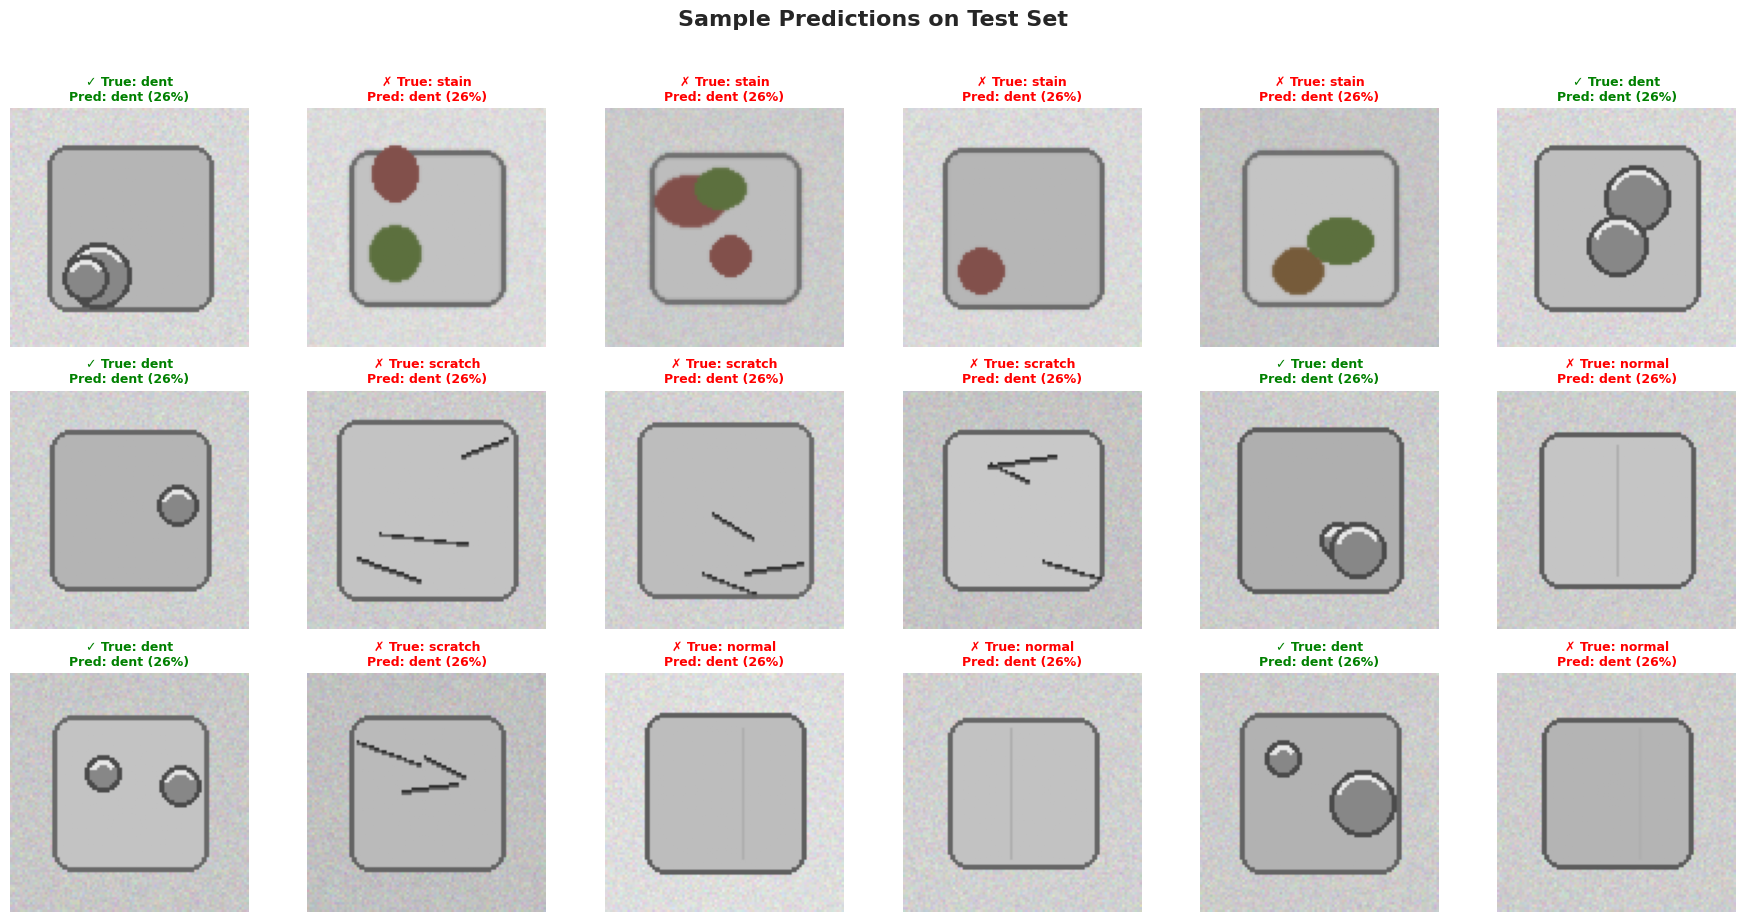

In [196]:
# Sample predictions on test images

plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Sample Predictions on Test Set', fontsize=16, fontweight='bold', y=1.02)

np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 18, replace=False)

for idx, ax in zip(sample_indices, axes.flatten()):
    ax.imshow(X_test[idx])
    true_label = le.classes_[y_true[idx]]
    pred_label = le.classes_[y_pred[idx]]
    confidence = y_pred_probs[idx][y_pred[idx]] * 100

    correct = true_label == pred_label
    color = 'green' if correct else 'red'
    symbol = '✓' if correct else '✗'

    ax.set_title(f'{symbol} True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)',
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()